# Hex tessellation — whole Baltic

Decompose the BSH wet region into hexes at three candidate radii (4, 6, 10 km)
to inform the resolution decision for the hex-aggregate store
(see `plans/hex_aggregate_store.md`). Whole-Baltic view, 12×12 inch figures.

In [1]:
from pathlib import Path
data_root = Path("../../data")

# Unified HexProj origin (matches 024 Baltic grid).
hp_origin = dict(projection_name="laea", lon_origin=18.0, lat_origin=59.0)
candidate_radii_m = [4_000, 6_000, 10_000]

# Baltic viz extent.
lon_min, lon_max = 5, 32
lat_min, lat_max = 53, 66

In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.ops import unary_union

from hextraj import HexProj

## Load data

In [3]:
wet_gdf = gpd.read_file(data_root / "BSH_model_coastline" / "coastline.geojson")
always_wet_gdf = gpd.read_file(data_root / "BSH_model_coastline" / "coastline_always_wet.geojson")
fucus_gdf = (
    gpd.read_file(data_root / "Fucus_location_shp" / "REDLIST_SIS_Macrophytes.shp")
    .query("F_vesiculo != 0")
    .to_crs(epsg=4326)
)

print(f"wet polygons: {len(wet_gdf)}")
print(f"always-wet polygons: {len(always_wet_gdf)}")
print(f"Fucus release cells: {len(fucus_gdf)}")

wet polygons: 8
always-wet polygons: 24
Fucus release cells: 872


## Wet-region union

Union across grid rows (fine + coarse) so `region_of_hexes` works on a single polygon.

In [4]:
wet_union = unary_union(wet_gdf.geometry)
print("wet union type:", wet_union.geom_type)

wet union type: MultiPolygon


## Per-resolution loop

In [5]:
def lonlat_aspect(lon_min_, lon_max_, lat_min_, lat_max_):
    """Width/height ratio that maps 1 deg lon ≈ 1 deg lat visually."""
    lat_mean = 0.5 * (lat_min_ + lat_max_)
    return ((lon_max_ - lon_min_) * np.cos(np.radians(lat_mean))) / (lat_max_ - lat_min_)

baltic_aspect = lonlat_aspect(lon_min, lon_max, lat_min, lat_max)

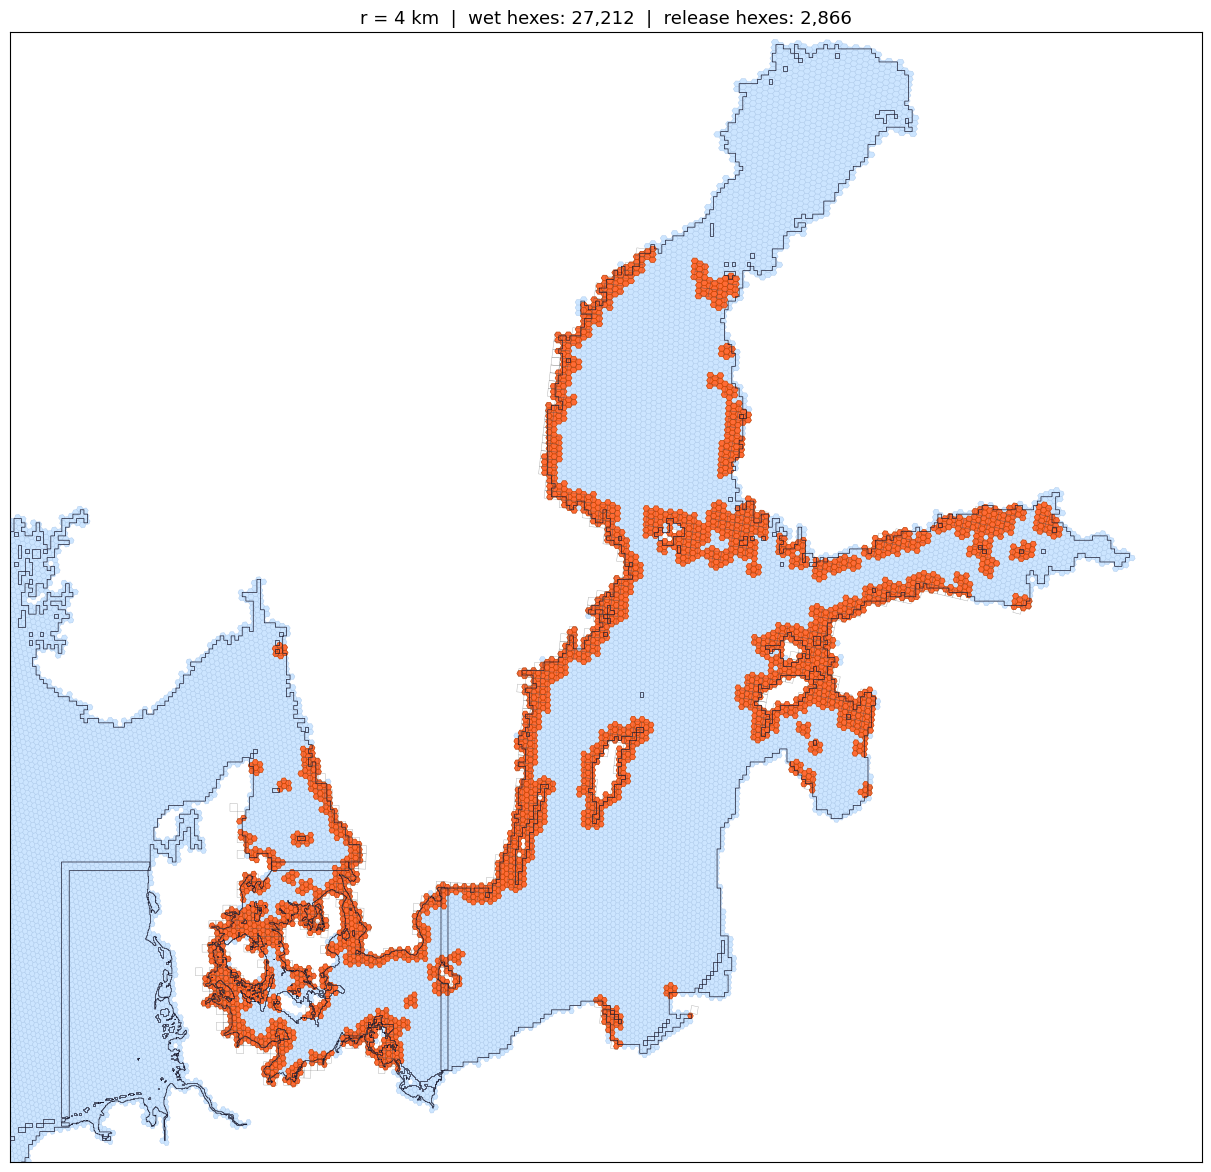

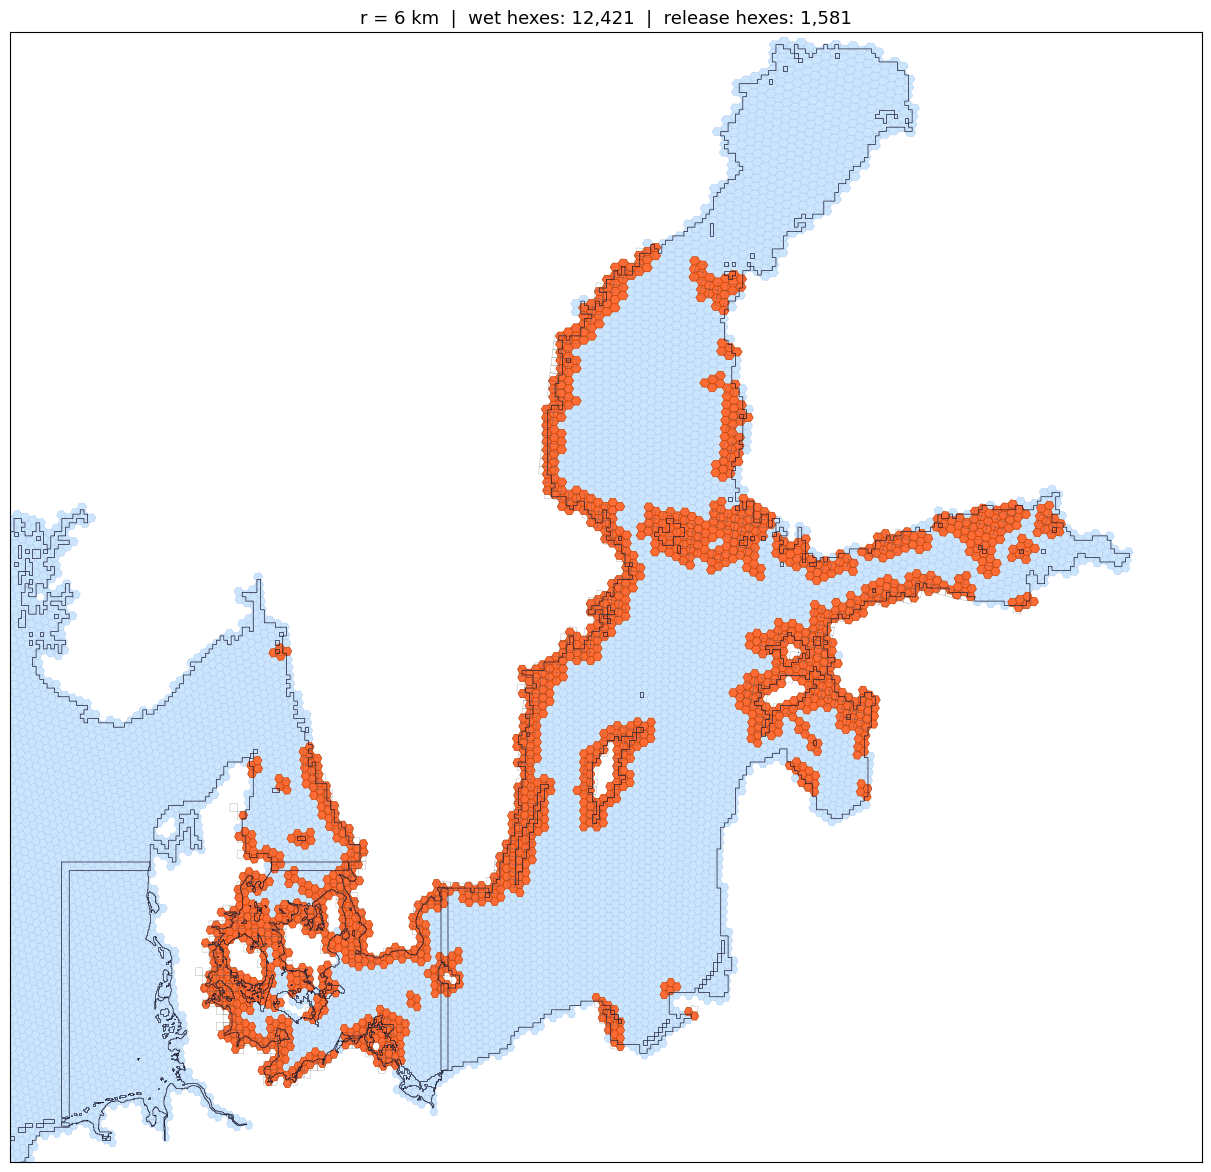

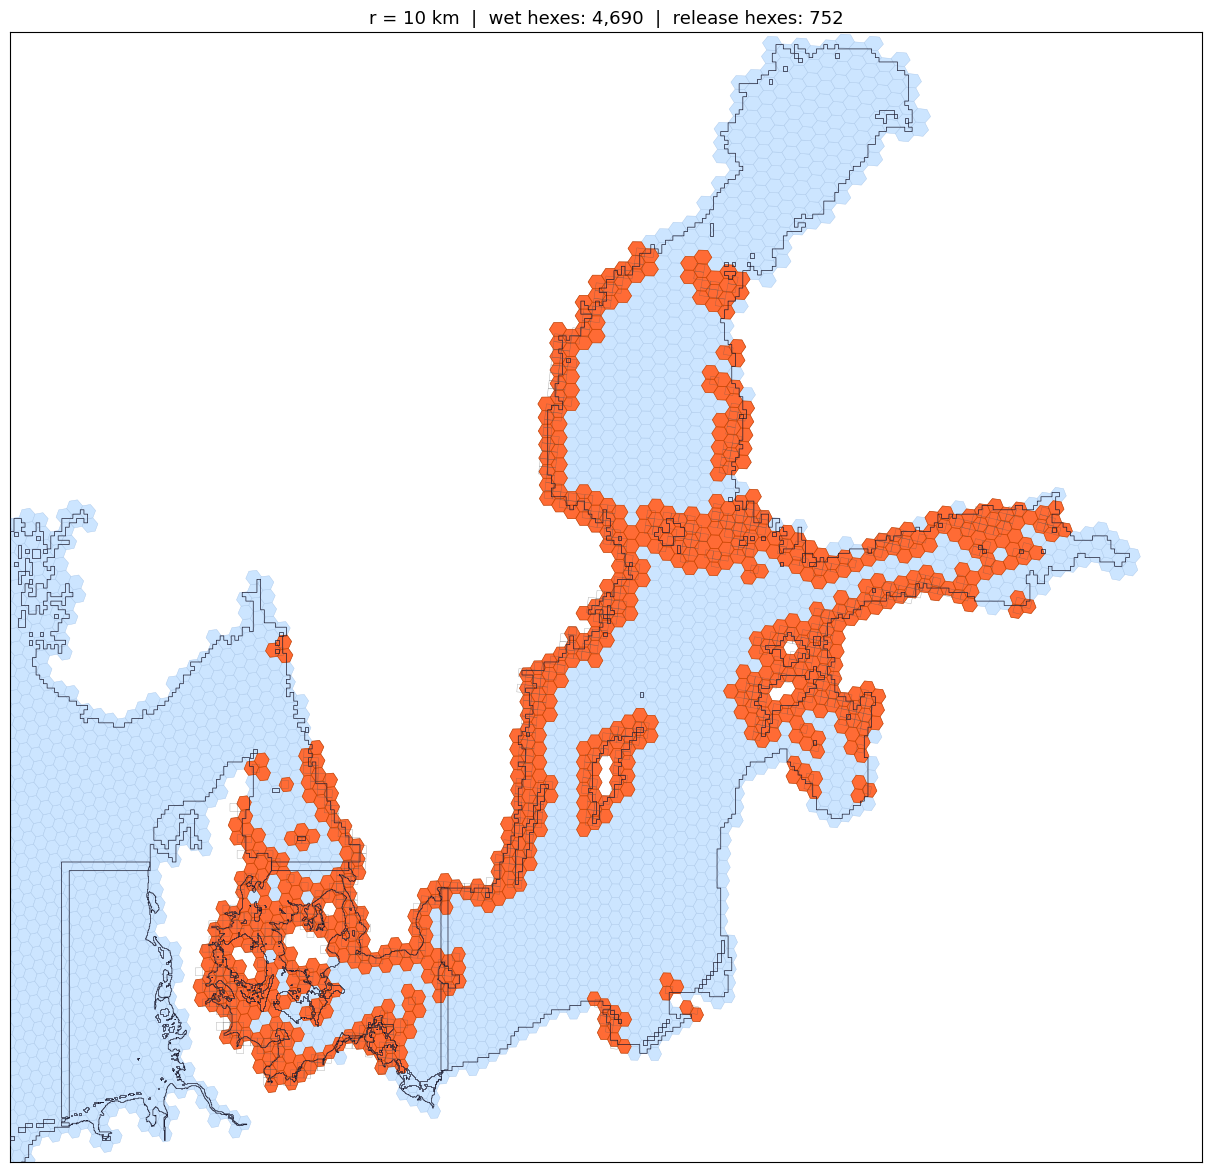

In [6]:
results = {}

for r in candidate_radii_m:
    hp = HexProj(**hp_origin, hex_size_meters=r)

    # Native helper: hexes whose polygons intersect the wet-region union.
    wet_ids = hp.region_of_hexes(wet_union)
    wet_hex = hp.to_geodataframe(wet_ids).dropna(subset=["geometry"])

    # Release hexes: sjoin with Fucus cells (intersects predicate).
    release_hex = gpd.sjoin(
        wet_hex,
        fucus_gdf[["geometry"]],
        how="inner",
        predicate="intersects",
    ).drop_duplicates(subset=None).loc[lambda df: ~df.index.duplicated()]

    n_wet = len(wet_hex)
    n_rel = len(release_hex)
    results[r] = dict(n_wet_hex=n_wet, n_release_hex=n_rel,
                      wet_hex=wet_hex, release_hex=release_hex)

    # --- figure ---
    fig, ax = plt.subplots(
        figsize=(12, 12),
        layout="constrained",
    )

    wet_hex.plot(ax=ax, color="#cce5ff", edgecolor="#aac8ea", linewidth=0.3, zorder=1)
    release_hex.plot(ax=ax, color="#ff6b35", edgecolor="#cc4400", linewidth=0.5, zorder=2)
    always_wet_gdf.boundary.plot(ax=ax, color="#1a1a2e", linewidth=0.5, zorder=3)
    fucus_gdf.boundary.plot(ax=ax, color="#555555", linewidth=0.3, alpha=0.5, zorder=4)

    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)
    ax.set_aspect(1 / np.cos(np.radians(0.5 * (lat_min + lat_max))))
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(
        f"r = {r/1000:.0f} km  |  wet hexes: {n_wet:,}  |  release hexes: {n_rel:,}",
        fontsize=13,
    )
    plt.show()

## Size-estimate summary

Row-count formula from `plans/hex_aggregate_store.md`:

```
n_rows ≈ 3 × 9 × 73 × n_release_hex × 22 × u_per_age
```

where `u_per_age` is the average number of distinct target hexes per
`(release_hex, release_doy, age_bin)` group.

Heuristic placeholder (±2× until a real aggregation pass):

```
traj_per_group = (9 × 73 × 872 × 100) / (9 × 73 × n_release_hex)
               = 872 × 100 / n_release_hex
u_per_age = min(2.5 × 10 × sqrt(traj_per_group) × 0.5, 0.6 × n_wet_hex)
```

In [7]:
rows = []
for r, d in results.items():
    n_wet = d["n_wet_hex"]
    n_rel = d["n_release_hex"]
    traj_per_group = (872 * 100) / n_rel if n_rel > 0 else 0
    u_per_age = min(2.5 * 10 * np.sqrt(traj_per_group) * 0.5, 0.6 * n_wet)
    n_rows = 3 * 9 * 73 * n_rel * 22 * u_per_age
    parquet_gb = n_rows * 6 / 1e9
    pandas_gb = n_rows * 28 / 1e9
    rows.append(dict(
        radius_km=r // 1000,
        n_wet_hex=n_wet,
        n_release_hex=n_rel,
        u_per_age=round(u_per_age, 1),
        n_rows_M=round(n_rows / 1e6, 1),
        parquet_GB=round(parquet_gb, 1),
        pandas_GB=round(pandas_gb, 1),
    ))

summary = pd.DataFrame(rows).set_index("radius_km")
print(summary.to_string())

           n_wet_hex  n_release_hex  u_per_age  n_rows_M  parquet_GB  pandas_GB
radius_km                                                                      
4              27212           2866       68.9    8568.7        51.4      239.9
6              12421           1581       92.8    6364.2        38.2      178.2
10              4690            752      134.6    4389.2        26.3      122.9
